# DDSP Timbre Transfer (Local)

This notebook loads a local DDSP checkpoint and resynthesizes audio using extracted f0 and loudness features.

Requirements: `ddsp`, `librosa`, `soundfile`, `tensorflow`, and `gin`.

In [15]:
import glob
import os
import pickle
import re
import time

import gin
import librosa
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import tensorflow.compat.v2 as tf

import ddsp
import ddsp.training
from ddsp.training.postprocessing import detect_notes, fit_quantile_transform
import sys
from pathlib import Path


# Add src to path to import baseline
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.analysis.visualize import plot_spectrograms

try:
    from ddsp.colab.colab_utils import auto_tune, get_tuning_factor
except Exception:
    auto_tune = None
    get_tuning_factor = None

DEFAULT_SAMPLE_RATE = 16000

def find_model_dir(path: str) -> str:
    if os.path.isfile(path) and path.endswith('.gin'):
        return os.path.dirname(path)
    gin_files = glob.glob(os.path.join(path, '*.gin'))
    if gin_files:
        return path
    for root, _, files in os.walk(path):
        for name in files:
            if name.endswith('.gin') and not name.startswith('.'):
                return root
    raise FileNotFoundError(f'No gin file found under {path}')

def find_latest_checkpoint(model_dir: str) -> str:
    ckpt_indexes = glob.glob(os.path.join(model_dir, 'ckpt-*.index'))
    if not ckpt_indexes:
        raise FileNotFoundError(f'No checkpoint found under {model_dir}')
    steps = []
    for path in ckpt_indexes:
        match = re.search(r'ckpt-(\d+)\.index$', path)
        if match:
            steps.append(int(match.group(1)))
    if not steps:
        raise FileNotFoundError(f'No checkpoint steps parsed under {model_dir}')
    step = max(steps)
    return os.path.join(model_dir, f'ckpt-{step}')

def load_dataset_stats(model_dir: str):
    stats_path = os.path.join(model_dir, 'dataset_statistics.pkl')
    if tf.io.gfile.exists(stats_path):
        with tf.io.gfile.GFile(stats_path, 'rb') as handle:
            return pickle.load(handle)
    return None

def shift_loudness(audio_features, ld_shift_db: float):
    audio_features['loudness_db'] += ld_shift_db
    return audio_features

def shift_f0(audio_features, pitch_shift: float):
    audio_features['f0_hz'] *= 2.0 ** pitch_shift
    audio_features['f0_hz'] = np.clip(
        audio_features['f0_hz'], 0.0, librosa.midi_to_hz(110.0)
    )
    return audio_features

def auto_adjust_features(audio_features, dataset_stats, threshold, quiet, autotune_amount):
    mask_on, note_on_value = detect_notes(
        audio_features['loudness_db'],
        audio_features['f0_confidence'],
        threshold,
    )
    if np.any(mask_on):
        target_mean_pitch = dataset_stats['mean_pitch']
        pitch = ddsp.core.hz_to_midi(audio_features['f0_hz'])
        mean_pitch = np.mean(pitch[mask_on])
        p_diff = target_mean_pitch - mean_pitch
        p_diff_octave = p_diff / 12.0
        round_fn = np.floor if p_diff_octave > 1.5 else np.ceil
        p_diff_octave = round_fn(p_diff_octave)
        audio_features = shift_f0(audio_features, p_diff_octave)

        _, loudness_norm = fit_quantile_transform(
            audio_features['loudness_db'],
            mask_on,
            inv_quantile=dataset_stats['quantile_transform'],
        )

        mask_off = np.logical_not(mask_on)
        loudness_norm[mask_off] -= quiet * (1.0 - note_on_value[mask_off][:, np.newaxis])
        loudness_norm = np.reshape(loudness_norm, audio_features['loudness_db'].shape)
        audio_features['loudness_db'] = loudness_norm

        if autotune_amount and auto_tune and get_tuning_factor:
            f0_midi = np.array(ddsp.core.hz_to_midi(audio_features['f0_hz']))
            tuning_factor = get_tuning_factor(
                f0_midi, audio_features['f0_confidence'], mask_on
            )
            f0_midi_at = auto_tune(
                f0_midi, tuning_factor, mask_on, amount=autotune_amount
            )
            audio_features['f0_hz'] = ddsp.core.midi_to_hz(f0_midi_at)
    return audio_features

def _to_numpy(value):
    if isinstance(value, tf.Tensor):
        return value.numpy()
    return value

def compute_features(audio):
    audio = tf.convert_to_tensor(audio, dtype=tf.float32)
    ddsp.spectral_ops.reset_crepe()
    audio_features = ddsp.training.metrics.compute_audio_features(audio)
    audio_features = tf.nest.map_structure(_to_numpy, audio_features)
    audio_features['loudness_db'] = audio_features['loudness_db'].astype(np.float32)
    return audio_features

def trim_features(audio_features, time_steps: int, n_samples: int):
    for key in ['f0_hz', 'f0_confidence', 'loudness_db']:
        audio_features[key] = audio_features[key][:time_steps]
    audio_features['audio'] = audio_features['audio'][:, :n_samples]
    return audio_features

def load_model(model_dir: str, gin_file: str, audio, audio_features):
    with gin.unlock_config():
        gin.parse_config_file(gin_file, skip_unknown=True)

    time_steps_train = gin.query_parameter('F0LoudnessPreprocessor.time_steps')
    n_samples_train = gin.query_parameter('Harmonic.n_samples')
    hop_size = int(n_samples_train / time_steps_train)

    time_steps = int(audio.shape[1] / hop_size)
    n_samples = time_steps * hop_size

    gin_params = [
        f'Harmonic.n_samples = {n_samples}',
        f'FilteredNoise.n_samples = {n_samples}',
        f'F0LoudnessPreprocessor.time_steps = {time_steps}',
        'oscillator_bank.use_angular_cumsum = True',
    ]
    with gin.unlock_config():
        gin.parse_config(gin_params)

    audio_features = trim_features(audio_features, time_steps, n_samples)

    model = ddsp.training.models.Autoencoder()
    ckpt = find_latest_checkpoint(model_dir)
    model.restore(ckpt)

    start_time = time.time()
    _ = model(audio_features, training=False)
    print(f'Restoring model took {time.time() - start_time:.1f} seconds')
    return model, audio_features

def resynthesize(model, audio_features):
    start_time = time.time()
    outputs = model(audio_features, training=False)
    audio_gen = model.get_audio_from_outputs(outputs)
    print(f'Prediction took {time.time() - start_time:.1f} seconds')
    audio_gen = np.array(audio_gen)[0]
    return audio_gen

def plot_features(audio_features, trim=-15):
    fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(6, 6))
    ax[0].plot(audio_features['loudness_db'][:trim])
    ax[0].set_ylabel('loudness_db')
    ax[1].plot(librosa.hz_to_midi(audio_features['f0_hz'][:trim]))
    ax[1].set_ylabel('f0 [midi]')
    ax[2].plot(audio_features['f0_confidence'][:trim])
    ax[2].set_ylabel('f0 confidence')
    ax[2].set_xlabel('frame')
    plt.show()


In [7]:
# Paths and parameters
project_root = '../../'
model_dir = project_root + 'artifacts/trained_models'
input_audio =  project_root +'data/voice/forte/f1_long_forte_a.wav'
output_audio =  project_root +'artifacts/sample_output/timbre_transfer.wav'
sample_rate = DEFAULT_SAMPLE_RATE

pitch_shift = 0.0
loudness_shift = 0.0
auto_adjust = False
threshold = 1.0
quiet = 20.0
autotune = 0.0


/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


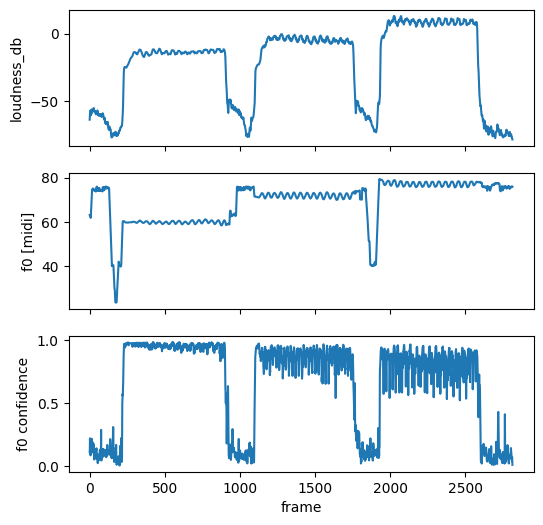

In [8]:
# Load audio and compute features
audio, _ = librosa.load(input_audio, sr=sample_rate, mono=True)
audio = audio[np.newaxis, :]
audio_features = compute_features(audio)
plot_features(audio_features)

In [9]:
# Load model, adjust features, resynthesize
model_dir = find_model_dir(model_dir)
gin_file = os.path.join(model_dir, 'operative_config-0.gin')
if not tf.io.gfile.exists(gin_file):
    gin_candidates = glob.glob(os.path.join(model_dir, '*.gin'))
    if not gin_candidates:
        raise FileNotFoundError('No gin file found in model_dir')
    gin_file = gin_candidates[0]

dataset_stats = load_dataset_stats(model_dir)
model, audio_features = load_model(model_dir, gin_file, audio, audio_features)

if auto_adjust and dataset_stats is not None:
    audio_features = auto_adjust_features(
        audio_features,
        dataset_stats,
        threshold=threshold,
        quiet=quiet,
        autotune_amount=autotune,
    )
audio_features = shift_loudness(audio_features, loudness_shift)
audio_features = shift_f0(audio_features, pitch_shift)

audio_gen = resynthesize(model, audio_features)

os.makedirs(os.path.dirname(output_audio), exist_ok=True)
sf.write(output_audio, audio_gen, sample_rate)
print(f'Wrote {output_audio}')

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/librosa/core/convert.py:1869: RuntimeWarning: divide by zero encountered in log10
  + 2 * np.log10(f_sq)


Restoring model took 2.1 seconds
Prediction took 1.7 seconds
Wrote ../../artifacts/sample_output/timbre_transfer.wav


In [10]:
# Listen back
from IPython.display import Audio, display
display(Audio(audio[0], rate=sample_rate))
display(Audio(audio_gen, rate=sample_rate))

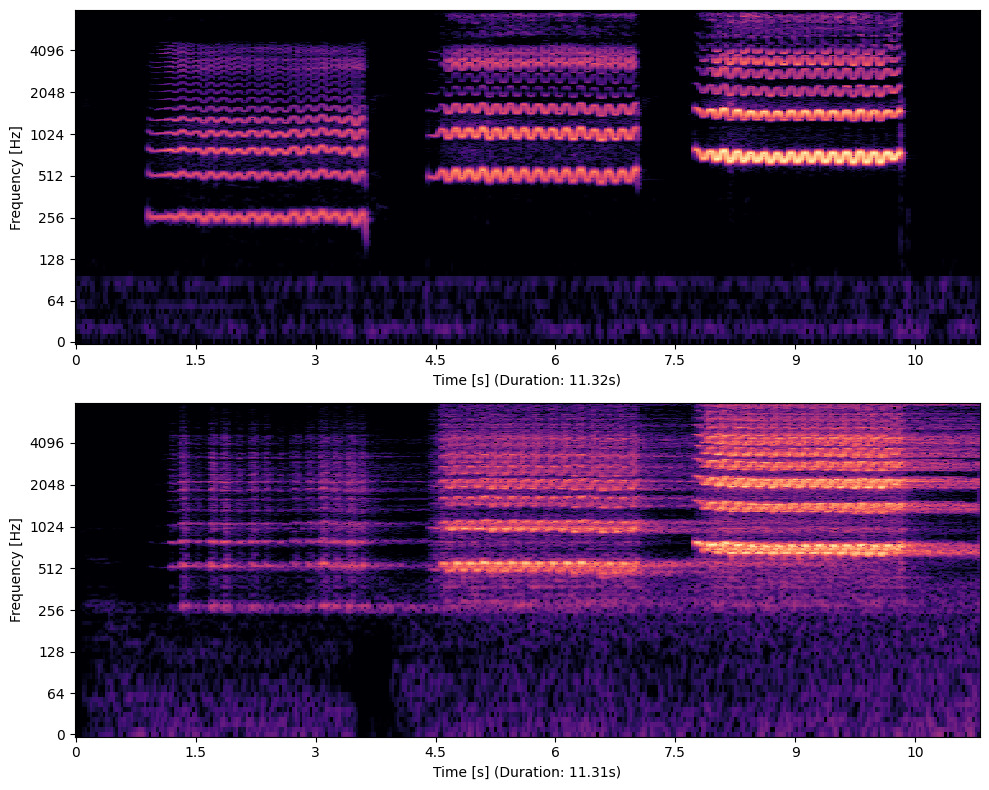

In [16]:
plot_spectrograms([audio[0], audio_gen], sample_rate)